600 images  (using 70-30 split, with 70 % training further split into 75% training and 25% validation)
       (180 testing images; 420 training images- 315 training 105 validation images)
Comdoenca – with the disease
Endoenca- without the disease

Image split
testing:
90 com, 90 sem
training:
315
157 com 158 sem
validation: 105
53 com 52 sem

Using transfer learning: VGG19, EfficientNetB3, ResNet50, DenseNet121

Fixed: drop-out (0.6, 0.4, 0.3), dense nodes (256, 128, 64), no of epochs:50, input size (256x256); batch size 32
 
Apply pre-processing techniques: normalization, image shuffling, augmentation, train-test split
Should have augmentation on the training images only

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras import ops
from keras.models import Sequential
from keras.layers import Dense, Dropout, Flatten, Conv2D, GlobalAveragePooling2D, MaxPool2D, BatchNormalization
from keras.applications.resnet50 import ResNet50
from keras.applications.vgg19 import VGG19
from keras.applications.efficientnet import EfficientNetB3
from keras.applications.densenet import DenseNet121
import tensorflow.keras.backend as K
from keras.callbacks import ModelCheckpoint

In [2]:
for dirname, _, filenames in os.walk('Dataset'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


Dataset\test\comdoença\cd (1).jpg
Dataset\test\comdoença\cd (10).jpg
Dataset\test\comdoença\cd (11).jpg
Dataset\test\comdoença\cd (12).jpg
Dataset\test\comdoença\cd (13).jpg
Dataset\test\comdoença\cd (14).jpg
Dataset\test\comdoença\cd (15).jpg
Dataset\test\comdoença\cd (16).jpg
Dataset\test\comdoença\cd (17).jpg
Dataset\test\comdoença\cd (18).jpg
Dataset\test\comdoença\cd (19).jpg
Dataset\test\comdoença\cd (2).jpg
Dataset\test\comdoença\cd (20).jpg
Dataset\test\comdoença\cd (21).jpg
Dataset\test\comdoença\cd (22).jpg
Dataset\test\comdoença\cd (23).jpg
Dataset\test\comdoença\cd (24).jpg
Dataset\test\comdoença\cd (25).jpg
Dataset\test\comdoença\cd (26).jpg
Dataset\test\comdoença\cd (27).jpg
Dataset\test\comdoença\cd (28).jpg
Dataset\test\comdoença\cd (29).jpg
Dataset\test\comdoença\cd (3).jpg
Dataset\test\comdoença\cd (30).jpg
Dataset\test\comdoença\cd (31).jpg
Dataset\test\comdoença\cd (32).jpg
Dataset\test\comdoença\cd (33).jpg
Dataset\test\comdoença\cd (34).jpg
Dataset\test\comdoença\

In [3]:
image_generatorFullAugment = ImageDataGenerator(
    rotation_range = 30,
    width_shift_range = 0.15,
    shear_range = 0.3,
    samplewise_center=True,
    horizontal_flip = True,
    samplewise_std_normalization = True
)

image_generatorNoAugment = ImageDataGenerator(
    samplewise_std_normalization = True
)

c:\Users\gab\AppData\Local\Python\pythoncore-3.12-64\Lib\site-packages\keras\src\legacy\preprocessing\image.py:1070: UserWarning: This ImageDataGenerator specifies `samplewise_std_normalization`, which overrides setting of `samplewise_center`.
  warnings.warn(


In [4]:
train = image_generatorFullAugment.flow_from_directory(
    "Dataset/train",
    batch_size = 32,
    class_mode = 'binary',
    target_size=(256, 256)
)

validation = image_generatorFullAugment.flow_from_directory(
    "Dataset/validation",
    batch_size = 1,
    class_mode = 'binary',
    target_size=(256, 256)
)

test = image_generatorFullAugment.flow_from_directory(
    "Dataset/test",
    batch_size = 1,
    class_mode = 'binary',
    target_size=(256, 256)
)

Found 315 images belonging to 2 classes.
Found 105 images belonging to 2 classes.
Found 180 images belonging to 2 classes.


Main Experiments: to run at LR=0.0001, 0.00001, 0.000001
Adam (Adaptive Moment Estimation optimizer)
Adagrad (Adaptive Gradient optimizer) 
Adamax (Maximum adaptive moment estimation optimizer)
AdaDelta
SGD (Stochastic Gradient Descent)
RMSProp (Root Mean Square Propagation optimizer)
	                  
Main Metric: Accuracy and AUC; but need to get all metrics (accuracy, recall, precision, specificity, F1-score and AUC)
Binary classification: With Disease (COmdoenca) vs Without Disease (Endoenca)   
 TOTAL MODELS: 3 learning rates x 6 optimizers x 4 pretrained models = 72 simulations

In [5]:
# def custom_precision(y_true, y_pred):
#     true_positives = K.sum(K.round(K.clip(y_true * y_pred, 0, 1)))
#     predicted_positives = K.sum(K.round(K.clip(y_pred, 0, 1)))
#     precision = true_positives / (predicted_positives + K.epsilon())
#     return precision

# def custom_recall(y_true, y_pred):
#     true_positives = K.sum(K.round(K.clip(y_true * y_pred, 0, 1)))
#     possible_positives = K.sum(K.round(K.clip(y_true, 0, 1)))
#     recall = true_positives / (possible_positives + K.epsilon())
#     return recall

# def custom_f1(y_true, y_pred):
#     precision = custom_precision(y_true, y_pred)
#     recall = custom_recall(y_true, y_pred)
#     return 2*((precision*recall)/(precision+recall+K.epsilon()))


In [6]:
class MetricsF1(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        print()
        precision = logs['precision']
        recall = logs['recall']
        if (precision + recall) > 0:
            f1_score = 2 * (precision * recall) / (precision + recall)
        else:
            f1_score = 0
        print("F1 SCORE TRAIN:", round(f1_score, 4))

        val_precision = logs['val_precision']
        val_recall = logs['val_recall']
        if (val_precision + val_recall) > 0:
            val_f1_score = 2 * (val_precision * val_recall) / (val_precision + val_recall)
        else:
            val_f1_score = 0
        print("F1 SCORE VALIDATION:", round(val_f1_score, 4))

In [7]:
# def as_keras_metric(method):
#     import functools
#     from keras import backend as K
#     import tensorflow as tf
#     @functools.wraps(method)
#     def wrapper(self, args, **kwargs):
#         """ Wrapper for turning tensorflow metrics into keras metrics """
#         value, update_op = method(self, args, **kwargs)
#         K.get_session().run(tf.local_variables_initializer())
#         with tf.control_dependencies([update_op]):
#             value = tf.identity(value)
#         return value
#     return wrapper

# @as_keras_metric
# def combined_metric(y_true, y_pred, curve='ROC'):
#     return (tf.keras.metrics.AUC(curve=curve) + tf.keras.metrics.Accuracy(y_true, y_pred))/2

In [8]:
# def combined_metric(y_true, y_pred):
#     metric1 = tf.keras.metrics.Accuracy(y_true, y_pred)
#     metric2 = tf.keras.metrics.AUC(y_true, y_pred)
#     # Return weighted combination (example)
#     return 0.5 * metric1 + 0.5 * metric2

In [9]:
# class combined_metric(tf.keras.callbacks.Callback):
#     def on_epoch_end(self, epoch, logs=None):
#         print()
        
#         val_accuracy = logs['val_accuracy']
#         val_auc = logs['val_auc']
#         combined_metric = (val_accuracy + val_auc) /2
#         return(combined_metric)

In [10]:
checkpoint1 = ModelCheckpoint(
    filepath='best_model.keras', # Path to save the model
    monitor='val_accuracy',         # Metric to monitor (e.g., 'val_accuracy')
    mode='max',                  # 'min' for loss, 'max' for accuracy
    save_best_only=True,         # Only save when the metric improves
    verbose=1                    # Prints a message when a new best is found
)

checkpoint2 = ModelCheckpoint(
    filepath='best_model.keras', # Path to save the model
    monitor='val_auc',         # Metric to monitor (e.g., 'val_accuracy')
    mode='max',                  # 'min' for loss, 'max' for accuracy
    save_best_only=True,         # Only save when the metric improves
    verbose=1                    # Prints a message when a new best is found
)

In [11]:
def set_model(model_name, lr, optimizer_name):
    print(f"RUNNING USING MODEL: {model_name} AND LEARNING RATE OF {lr} ON {optimizer_name}")
    if model_name == "resnet":
        base_model = ResNet50(include_top=False, weights='imagenet')
    elif model_name == "densenet":
        base_model = DenseNet121(include_top=False, weights='imagenet')
    if model_name == "efficientnet":
        base_model = EfficientNetB3(include_top=False, weights='imagenet')
    elif model_name == "vgg":
        base_model = VGG19(include_top=False, weights='imagenet')

    base_model.trainable = False
        #resnet_base_model.summary()

    curr_model = tf.keras.Sequential([
        base_model,
        GlobalAveragePooling2D(),
        Dense(256, activation = "relu"),
        BatchNormalization(),
        Dropout(0.6),
        Dense(128, activation = "relu"),
        BatchNormalization(),
        Dropout(0.4),
        Dense(64, activation = "relu"),
        BatchNormalization(),
        Dropout(0.3),
        Dense(1, activation="sigmoid")
    ])

    if optimizer_name == "adam":
        opt = tf.keras.optimizers.Adam(learning_rate=lr)
    elif optimizer_name == "adagrad":
        opt = tf.keras.optimizers.Adagrad(learning_rate=lr)
    elif optimizer_name == "adamax":
        opt = tf.keras.optimizers.Adamax(learning_rate=lr)
    elif optimizer_name == "adadelta":
        opt = tf.keras.optimizers.Adadelta(learning_rate=lr)
    elif optimizer_name == "sgd":
        opt = tf.keras.optimizers.SGD(learning_rate=lr)
    elif optimizer_name == "rmsp":
        opt = tf.keras.optimizers.RMSprop(learning_rate=lr)

    
    metrics = [
        'accuracy', #custom_f1,
        #combined_metric, #acc and auc
        #tf.keras.metrics.F1Score(average='macro', threshold=0.5),
        tf.keras.metrics.Precision(name = 'precision'),
        tf.keras.metrics.Recall(name = 'recall'),
        tf.keras.metrics.AUC(name = 'auc'), #main
        #tf.keras.metrics.Accuracy(name = 'accuracy'), #main
        tf.keras.metrics.SpecificityAtSensitivity(sensitivity =0.5, num_thresholds = 200, name = 'specificity')#,
        #custom_f1
    ]
    #my_metric = tf.keras.metrics.AnyMetric(*args, **kwargs)

    curr_model.compile(optimizer=opt, loss='binary_crossentropy', metrics=metrics)
    #curr_model.reset_metrics()
    run_model = curr_model.fit(train, epochs = 50, validation_data= validation, callbacks = [MetricsF1(), checkpoint1])
    #curr_model.save(f"models/best-{model_name}-{optimizer_name}-{lr}.keras")
    #if os.path.exists("best_model.keras"):
       # os.remove("best_model.keras")

    plt.figure(figsize=(12,8))
    plt.subplot(2,2,1)
    plt.plot(run_model.history['loss'],label = "Loss")
    plt.plot(run_model.history['val_loss'],label = "Val_Loss")
    plt.legend()
    plt.title('Loss Evolution')
    plt.savefig(f"outputs/{model_name}-{optimizer_name}-{lr}.loss.png")


    plt.subplot(2,2,2)
    plt.plot(run_model.history['accuracy'],label = "Accuracy")
    plt.plot(run_model.history['val_accuracy'],label = "Val_Accuracy")
    plt.legend()
    plt.title('Accuracy Evolution')
    plt.savefig(f"outputs/{model_name}-{optimizer_name}-{lr}.acc.png")

    plt.subplot(2,2,3)
    plt.plot(run_model.history['auc'],label = "AUC")
    plt.plot(run_model.history['val_auc'],label = "Val_AU")
    plt.legend()
    plt.title('AUC Evolution')
    plt.savefig(f"outputs/{model_name}-{optimizer_name}-{lr}.auc.png")

    
    #pred_run_model = curr_model.predict(test)
    #print(confusion_matrix(test.classes, pred_run_model > 0.5))
    #pd.DataFrame(classification_report(test.classes, pred_run_model > 0.5, output_dict = True))

    #f1_score = 2 * (run_model.history['precision'], * run_model.history['recall'],) / (run_model.history['precision'], + run_model.history['recall'],)
    #print(f1_score)
    

In [12]:
# import gc
# K.clear_session()
# if 'run_model' in globals():
#     del run_model
# if 'curr_model' in globals():
#     del curr_model

# # 3. Force garbage collection
# gc.collect()

RUNNING USING MODEL: resnet AND LEARNING RATE OF 0.0001 ON adam
Epoch 1/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.4687 - auc: 0.4521 - loss: 1.0272 - precision: 0.4796 - recall: 0.4731 - specificity: 0.4588
F1 SCORE TRAIN: 0.5171
F1 SCORE VALIDATION: 0

Epoch 1: val_accuracy improved from None to 0.50476, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
10/10 ━━━━━━━━━━━━━━━━━━━━ 48s 4s/step - accuracy: 0.5079 - auc: 0.4858 - loss: 0.9804 - precision: 0.5092 - recall: 0.5253 - specificity: 0.5159 - val_accuracy: 0.5048 - val_auc: 0.4490 - val_loss: 0.8694 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - val_specificity: 0.4528
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5851 - auc: 0.5904 - loss: 0.8761 - precision: 0.5642 - recall: 0.6440 - specificity: 0.6620
F1 SCORE TRAIN: 0.6149
F1 SCORE VALIDATION: 0

Epoch 2: val_accuracy did not improve from 0.50476
10/10 ━━━━━━━━━━━━━━━━━━━━ 33s 3s/step - accuracy: 0.606

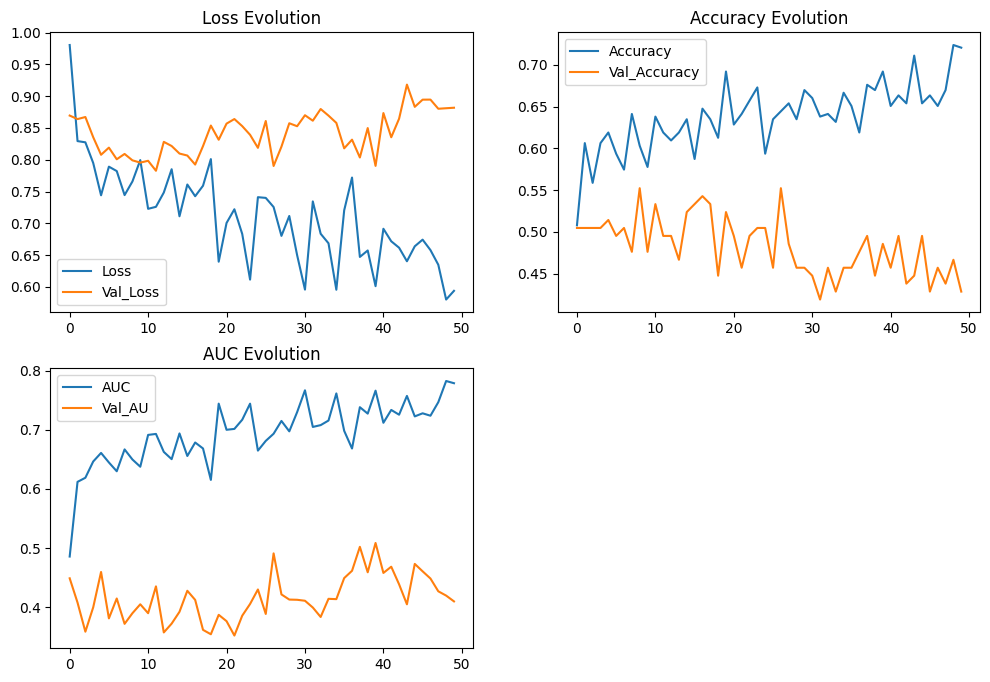

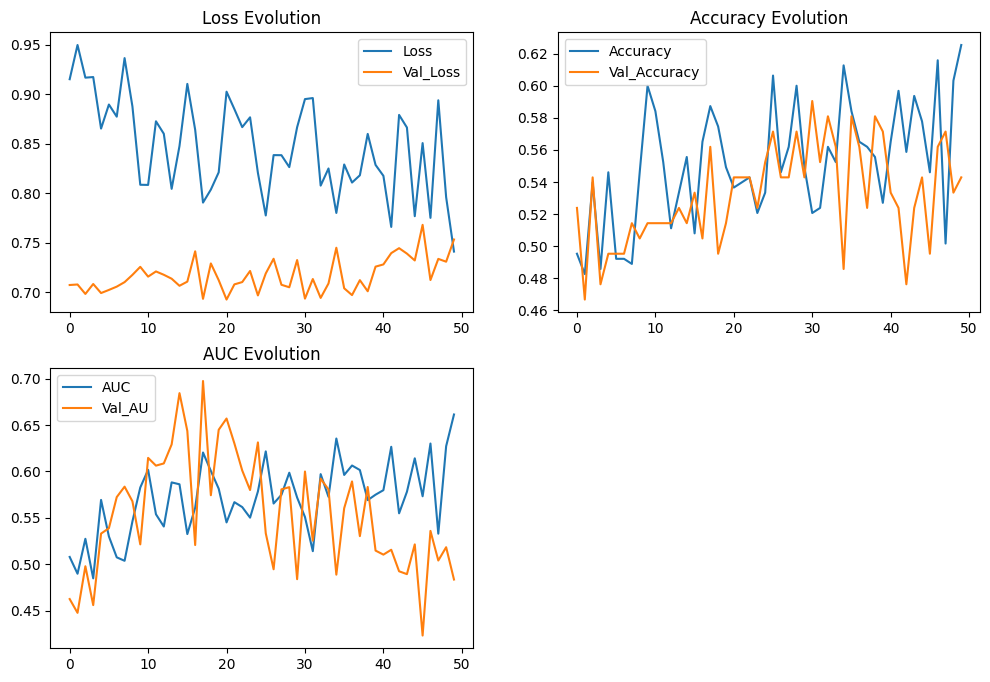

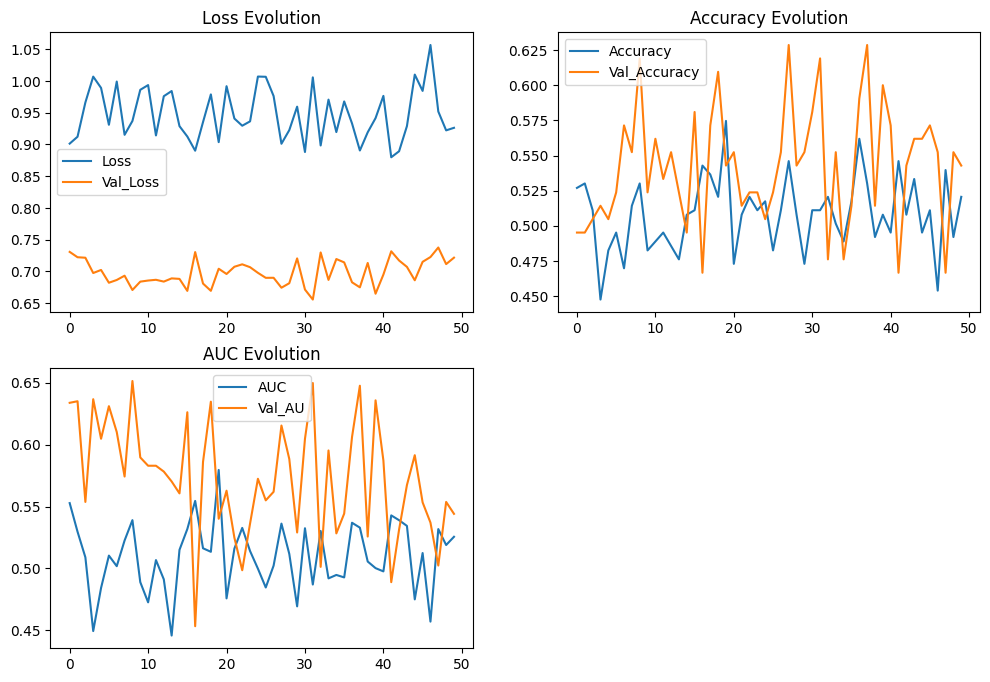

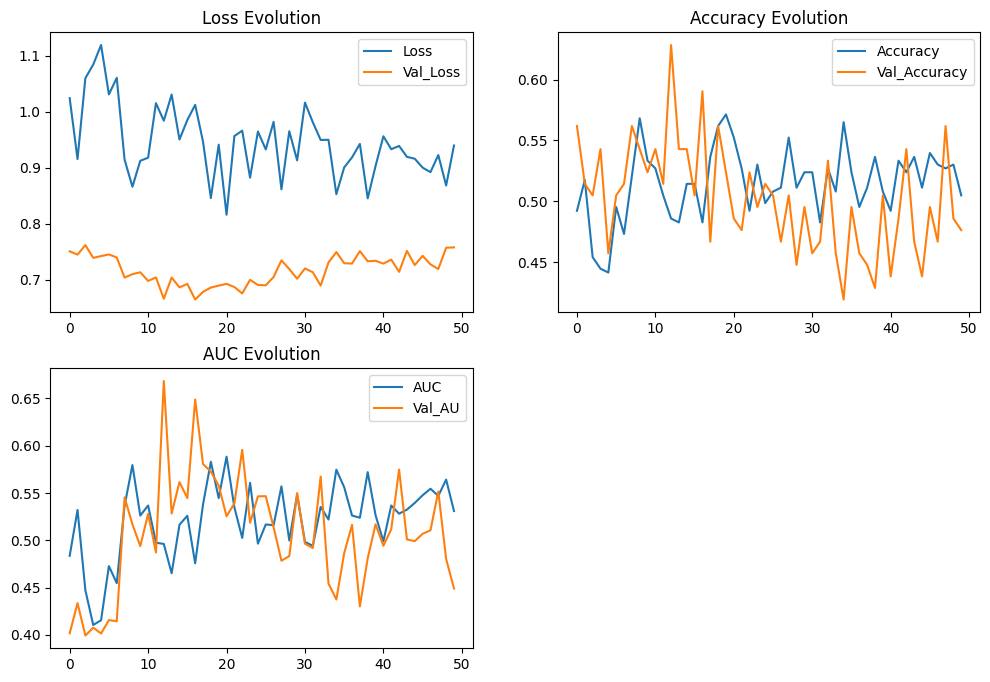

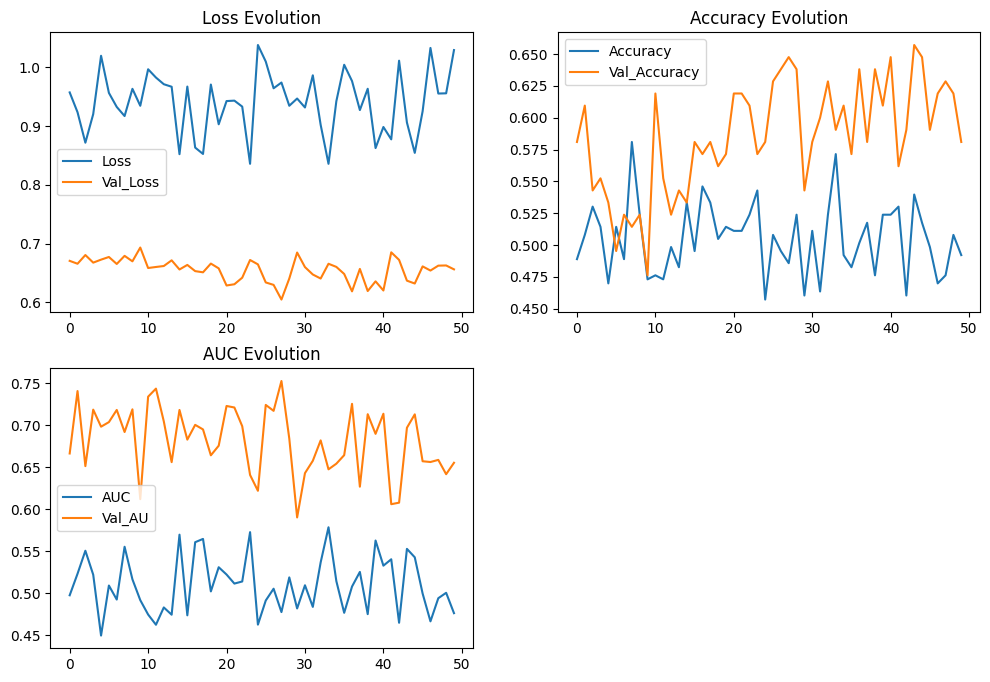

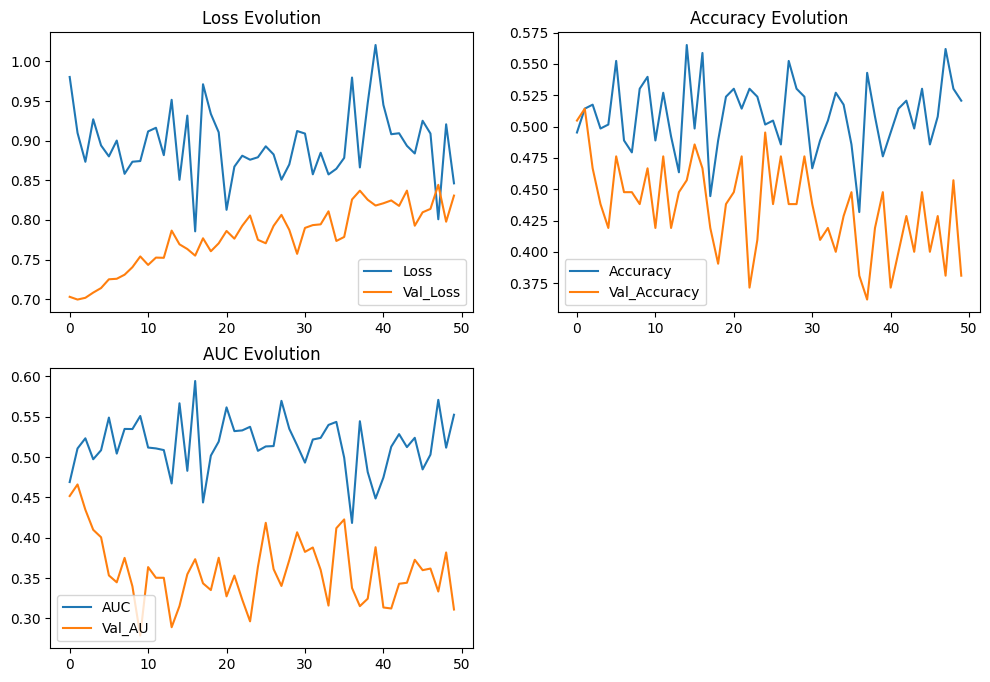

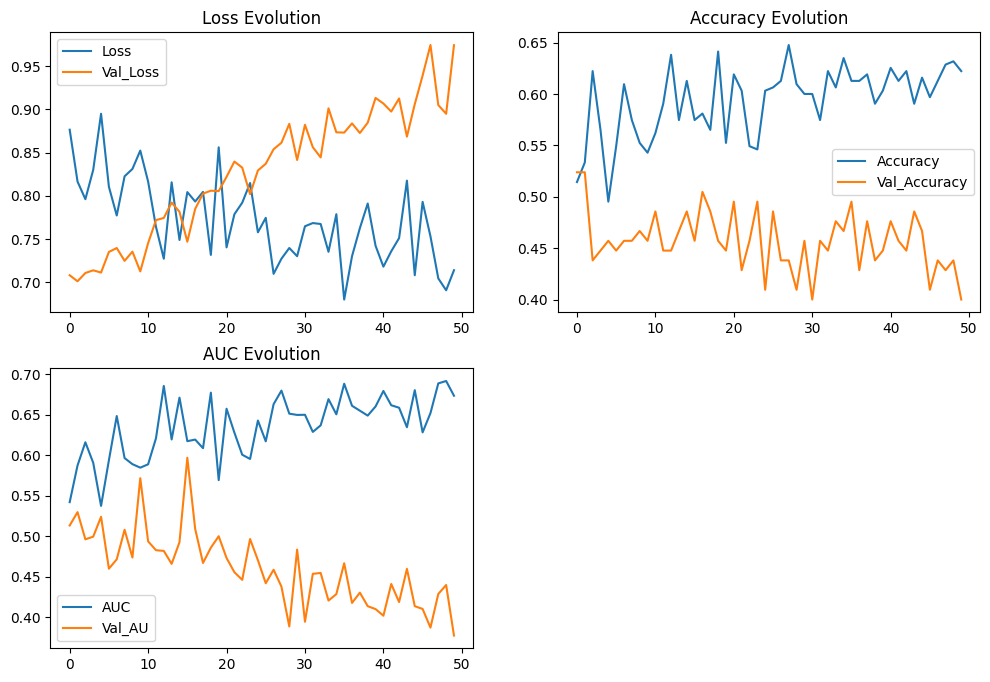

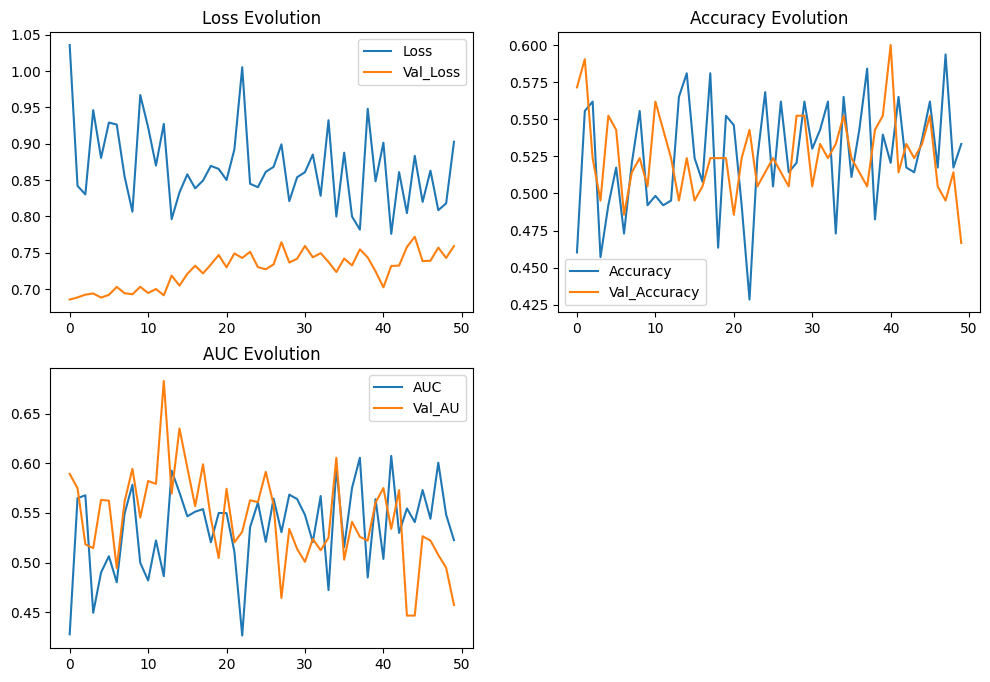

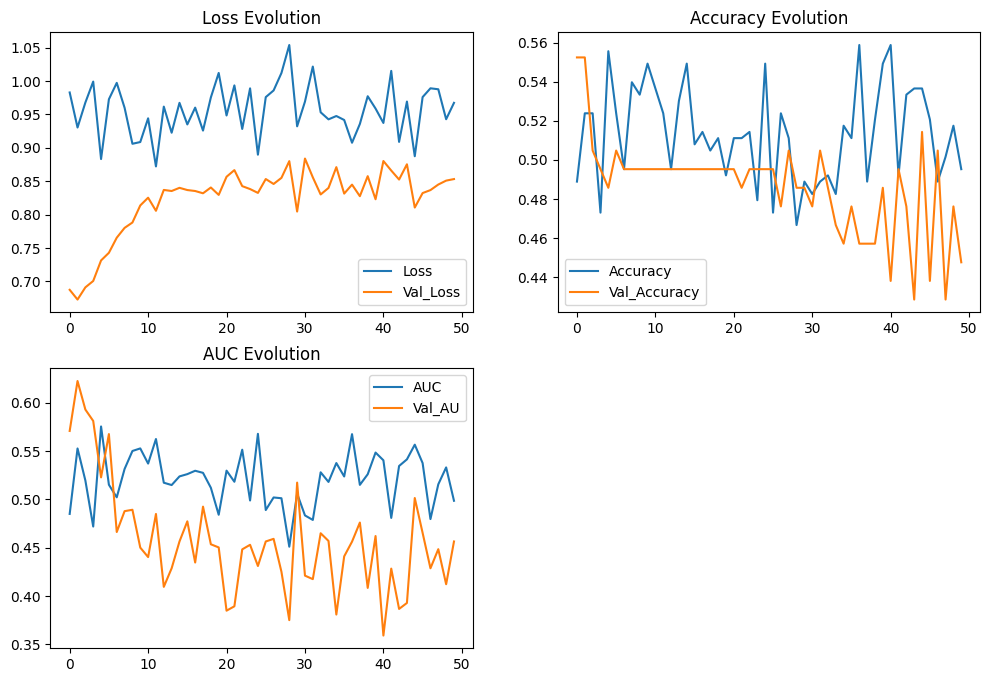

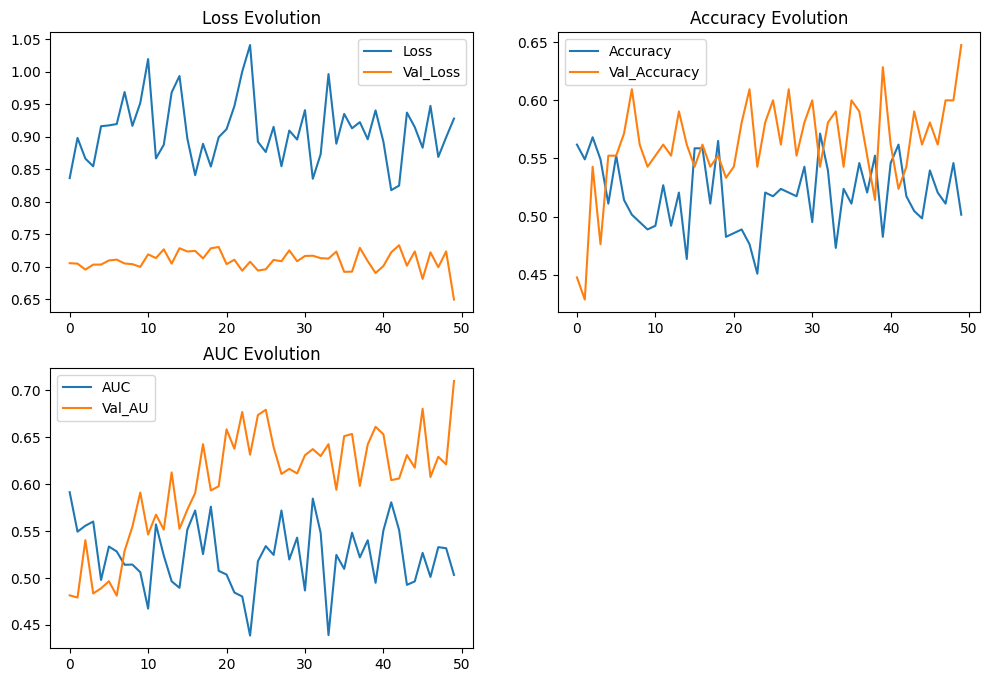

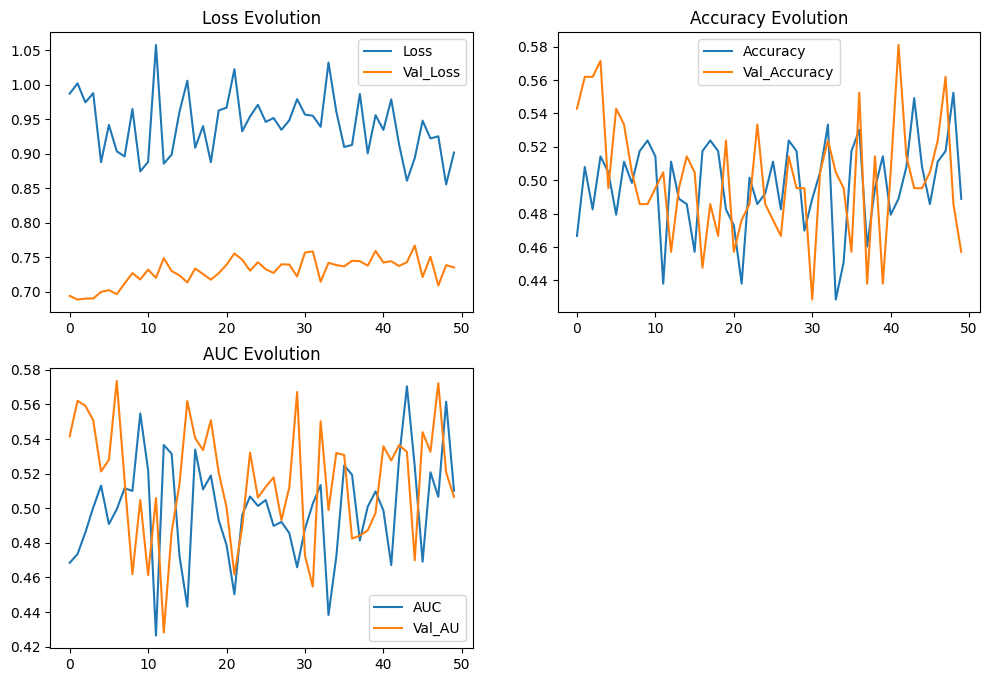

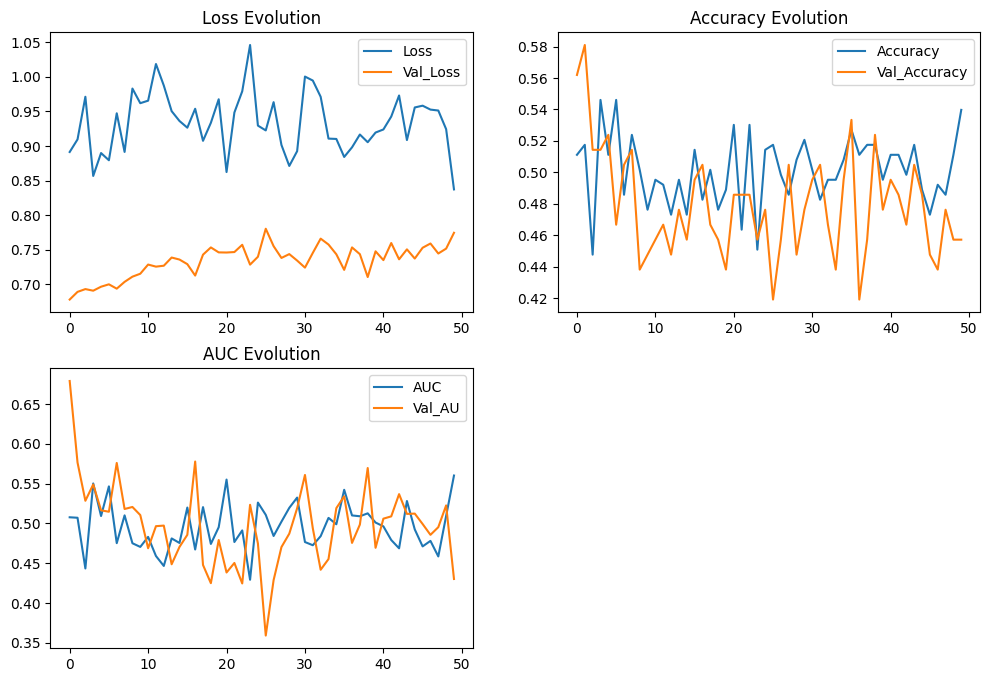

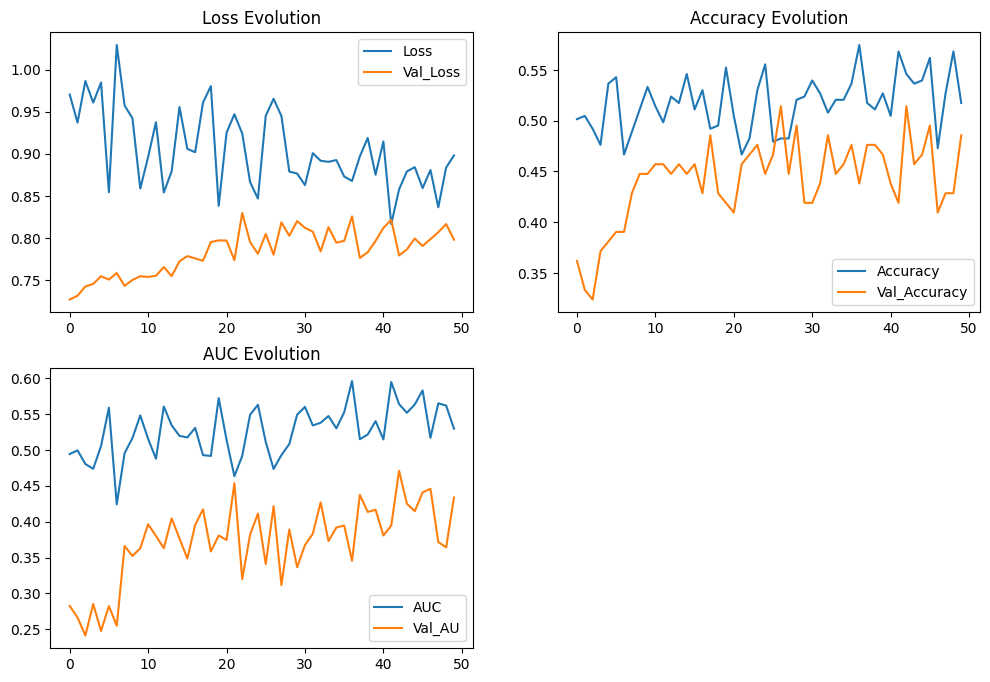

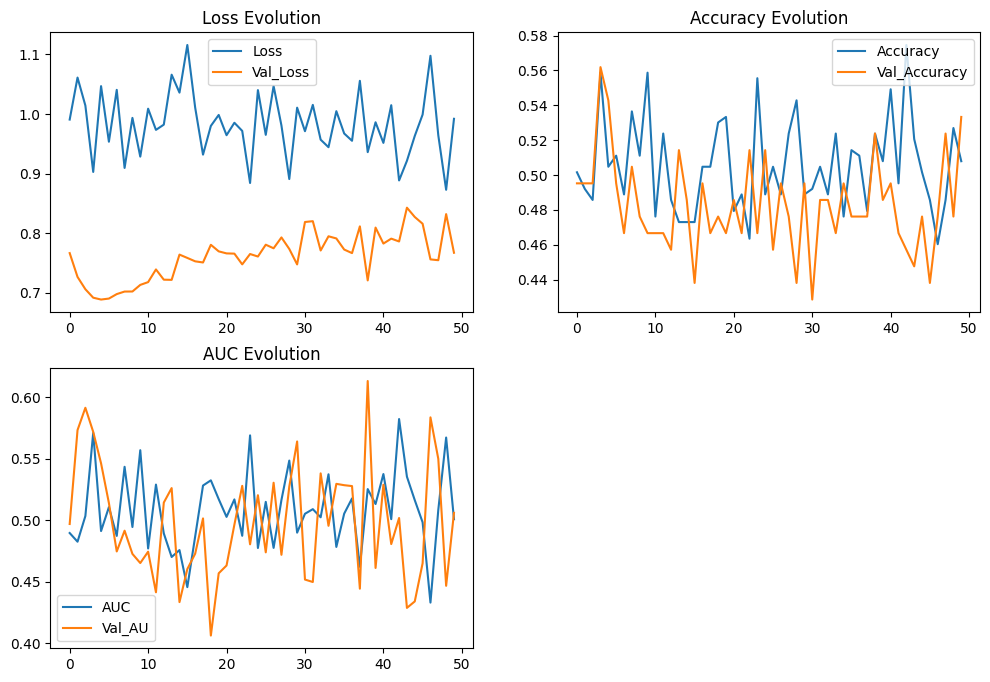

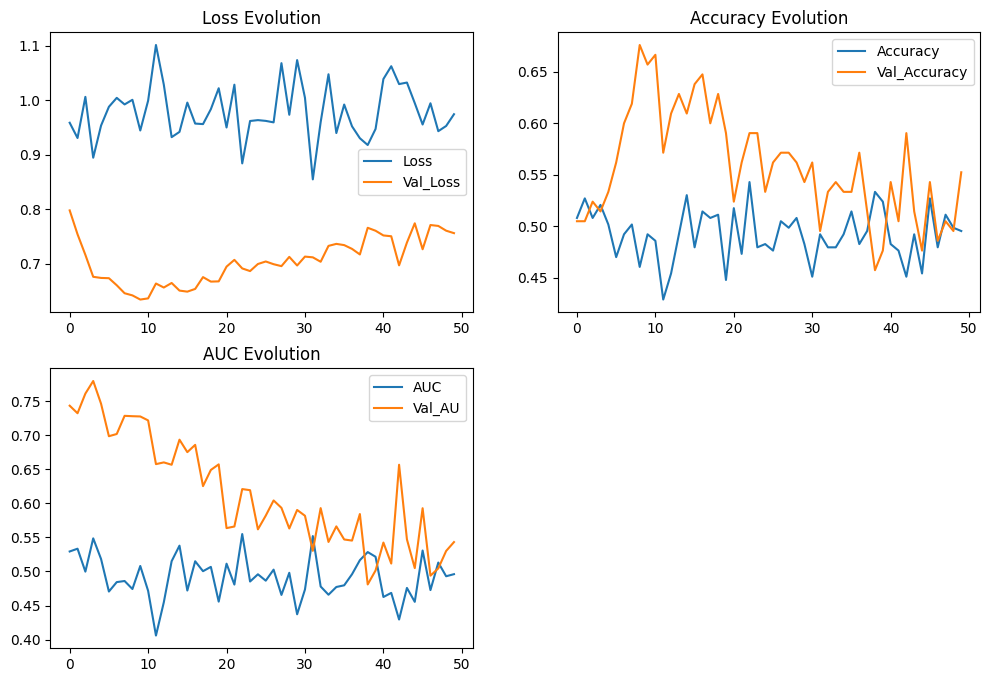

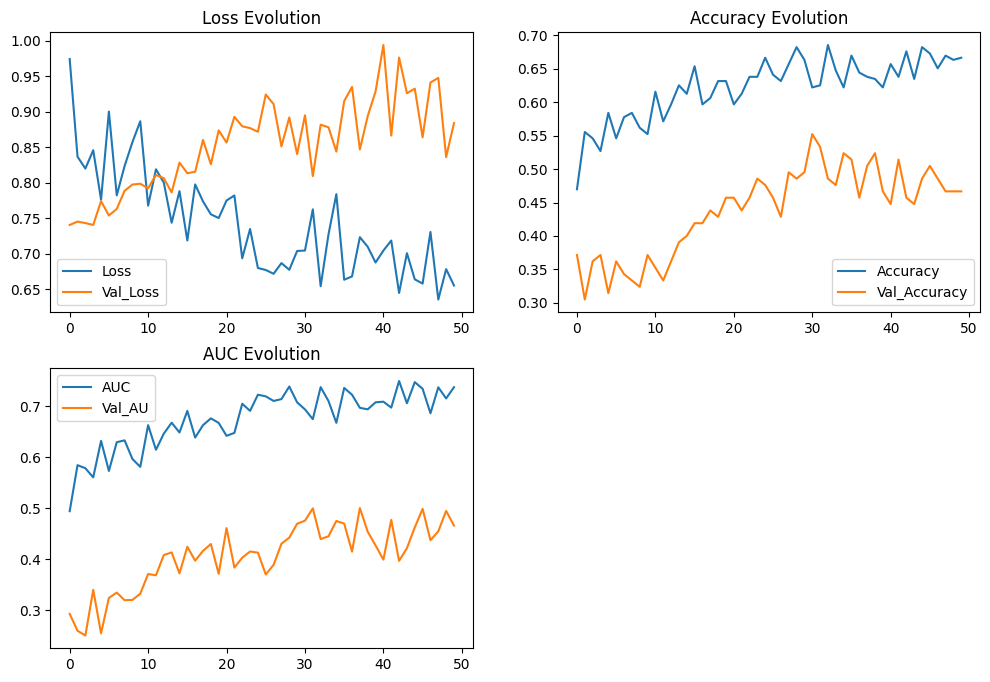

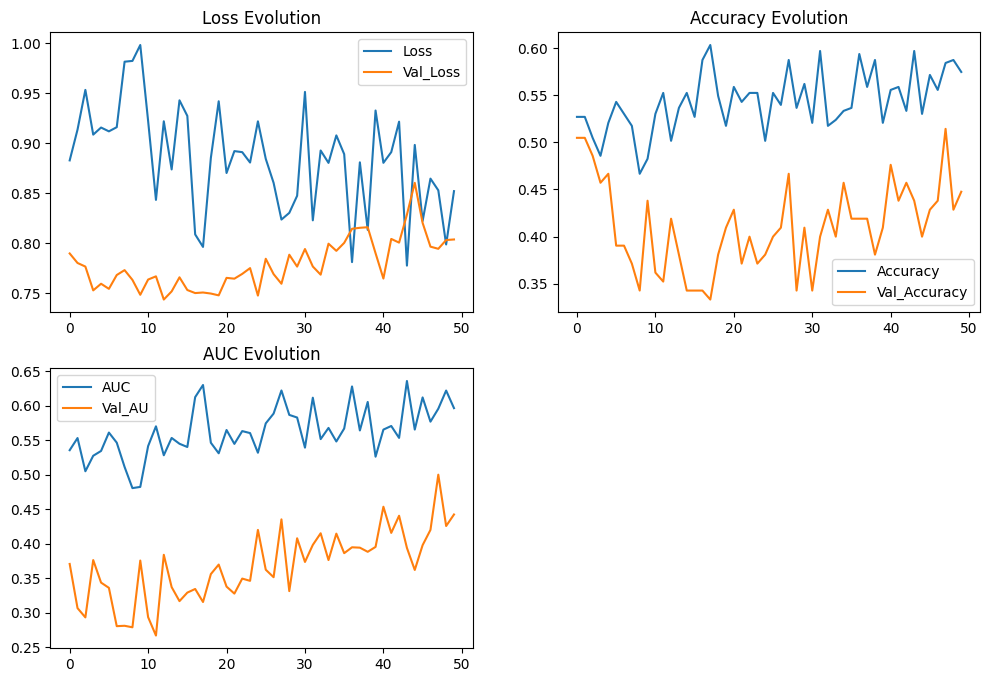

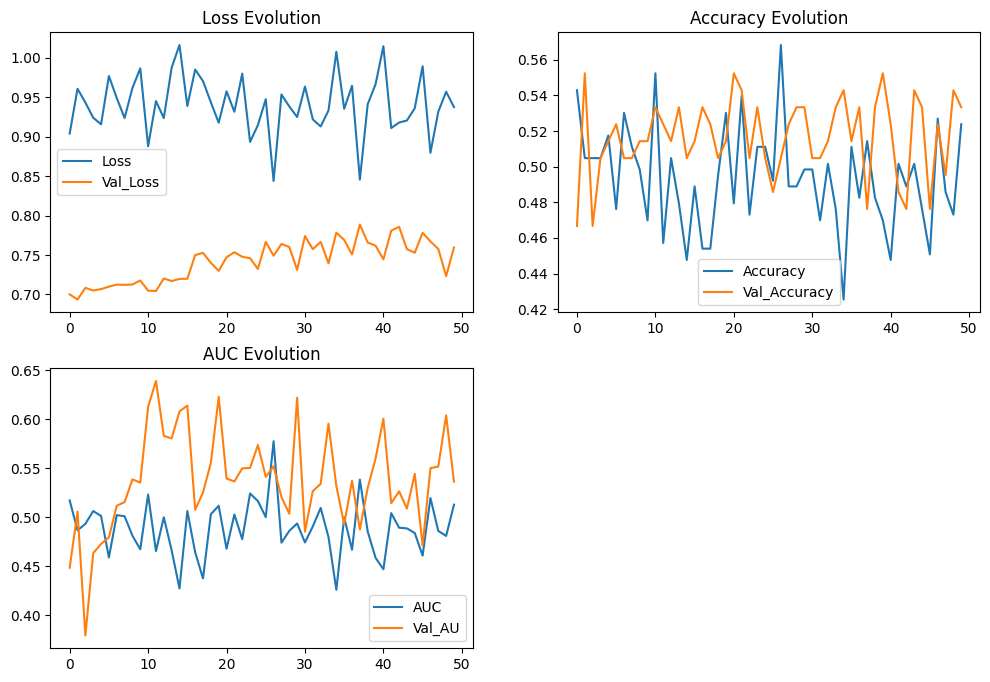

In [13]:
#resnet
set_model("resnet", 0.0001, "adam")
set_model("resnet", 0.00001, "adam")
set_model("resnet", 0.000001, "adam")

set_model("resnet", 0.0001, "adagrad")
set_model("resnet", 0.00001, "adagrad")
set_model("resnet", 0.000001, "adagrad")

set_model("resnet", 0.0001, "adamax")
set_model("resnet", 0.00001, "adamax")
set_model("resnet", 0.000001, "adamax")

set_model("resnet", 0.0001, "adadelta")
set_model("resnet", 0.00001, "adadelta")
set_model("resnet", 0.000001, "adadelta")

set_model("resnet", 0.0001, "sgd")
set_model("resnet", 0.00001, "sgd")
set_model("resnet", 0.000001, "sgd")

set_model("resnet", 0.0001, "rmsp")
set_model("resnet", 0.00001, "rmsp")
set_model("resnet", 0.000001, "rmsp")

RUNNING USING MODEL: densenet AND LEARNING RATE OF 0.0001 ON adam
29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
Epoch 1/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.4615 - auc: 0.4744 - loss: 0.9840 - precision: 0.4718 - recall: 0.4654 - specificity: 0.4326
F1 SCORE TRAIN: 0.4783
F1 SCORE VALIDATION: 0.4082

Epoch 1: val_accuracy did not improve from 0.67619
10/10 ━━━━━━━━━━━━━━━━━━━━ 52s 4s/step - accuracy: 0.4667 - auc: 0.5069 - loss: 0.9108 - precision: 0.4695 - recall: 0.4873 - specificity: 0.4395 - val_accuracy: 0.4476 - val_auc: 0.4604 - val_loss: 0.7162 - val_precision: 0.4348 - val_recall: 0.3846 - val_specificity: 0.3774
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.4644 - auc: 0.4652 - loss: 1.0063 - precision: 0.4401 - recall: 0.4733 - specificity: 0.4050
F1 SCORE TRAIN: 0.4732
F1 SCORE VALIDATION: 0.5321

Epoch 2: val_accuracy did not improve from 0.67619
10/10 ━━━━━━━━━━━━━━━━━━━━ 34s 3s/step - accuracy: 0.4698 - auc: 0.4600 - loss: 1.0089 -

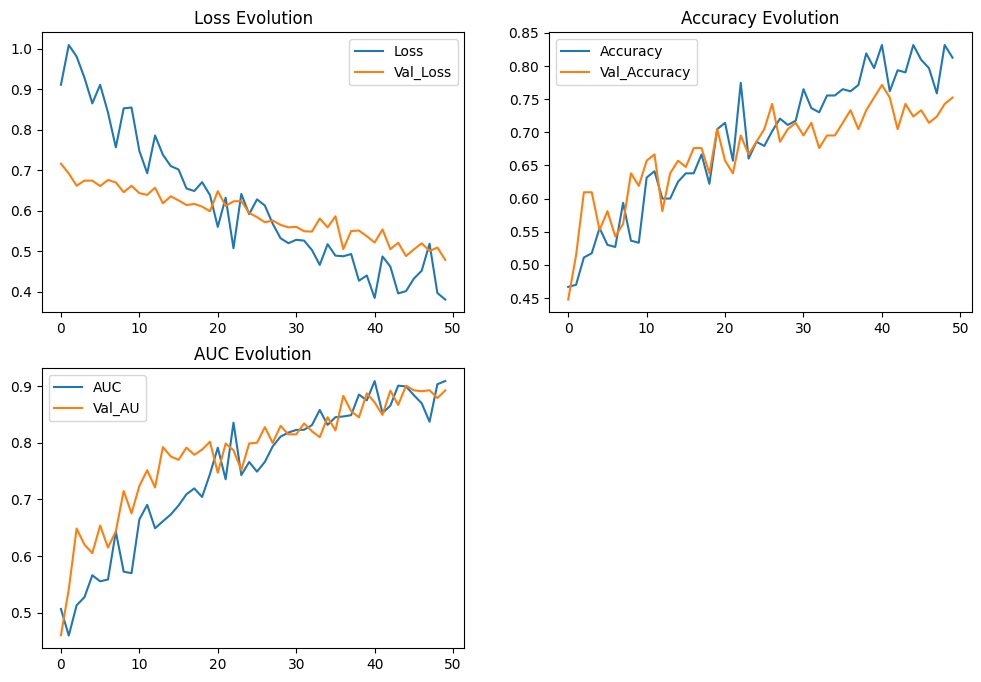

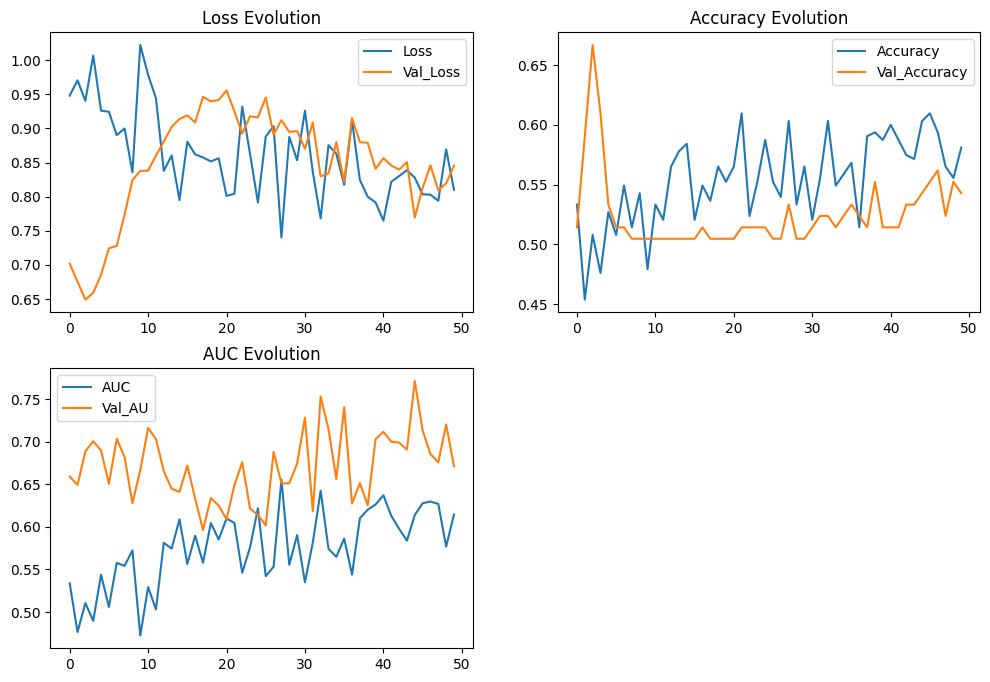

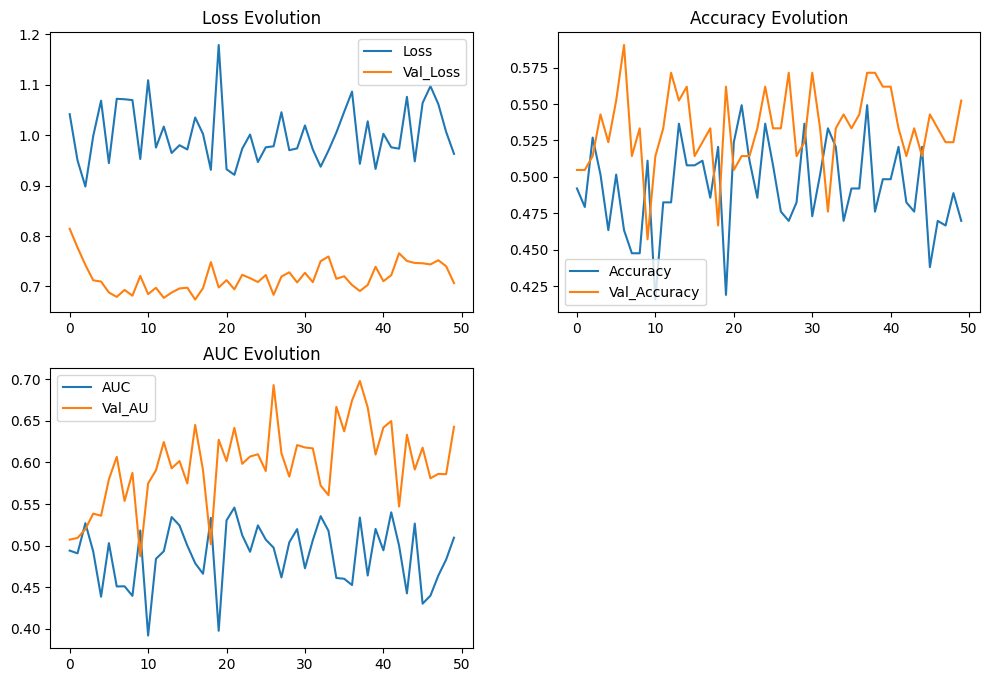

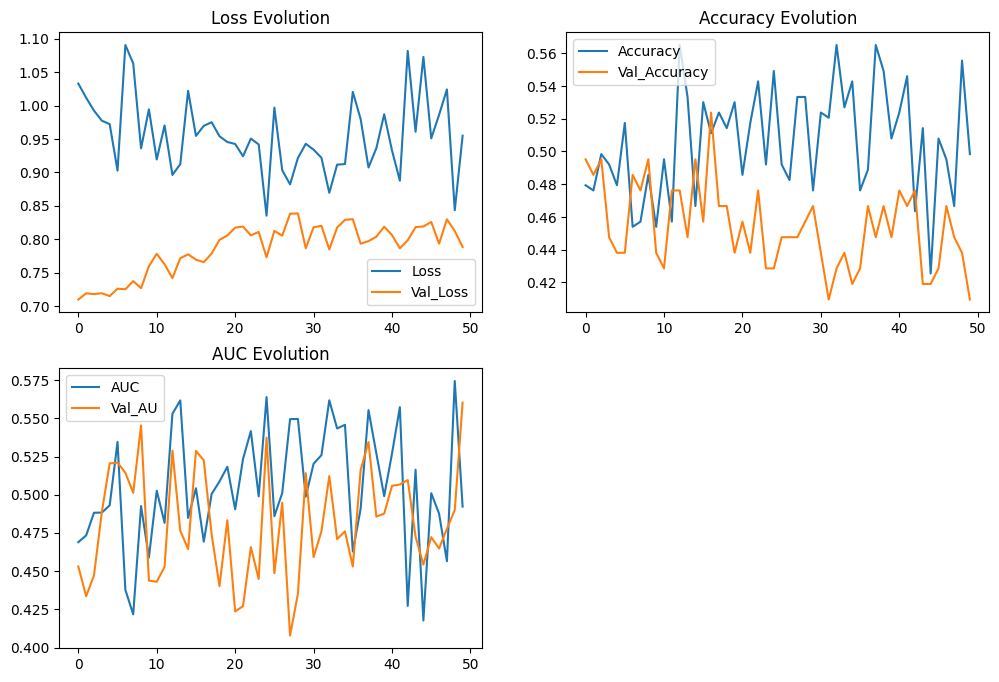

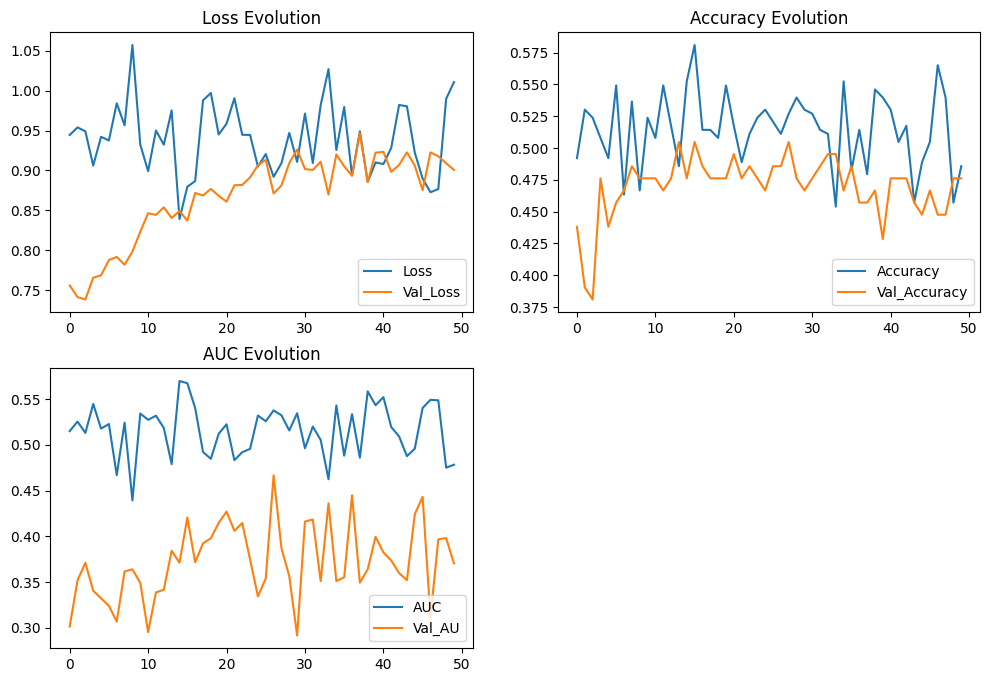

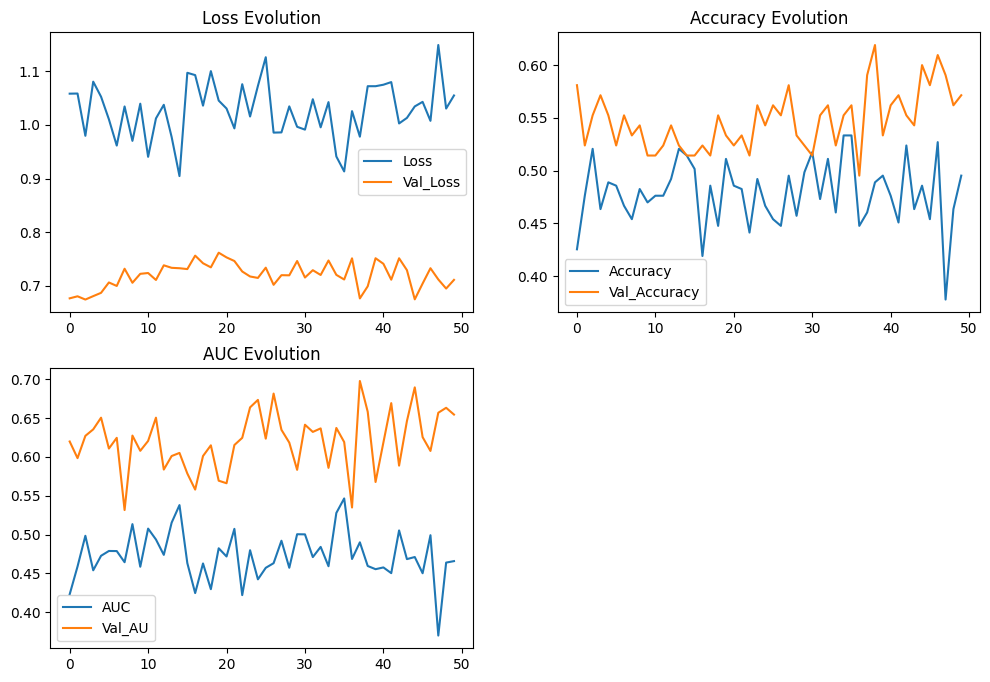

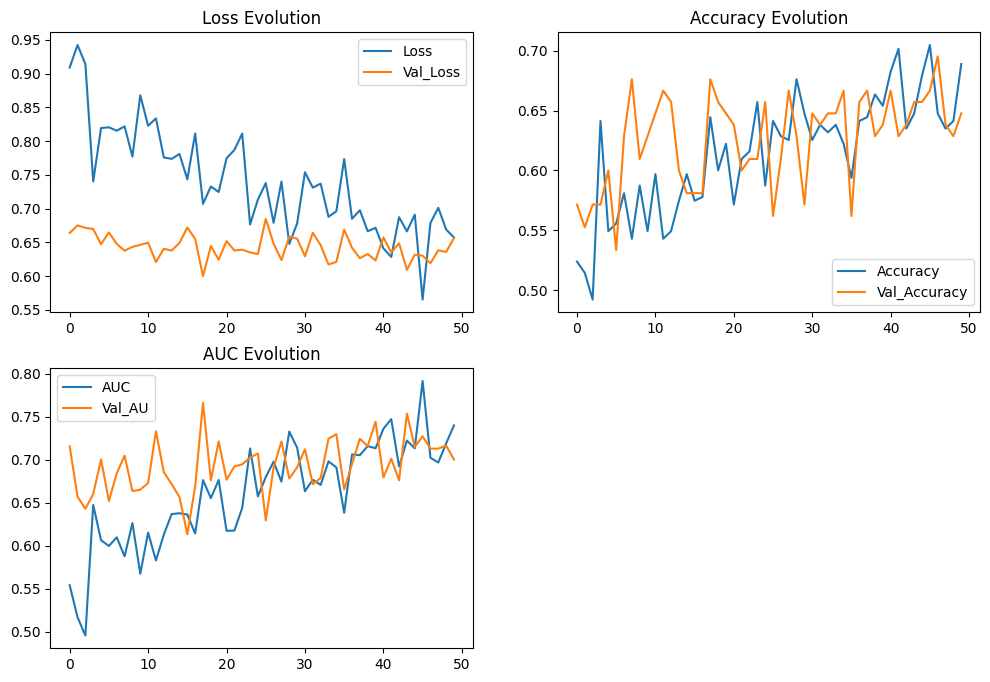

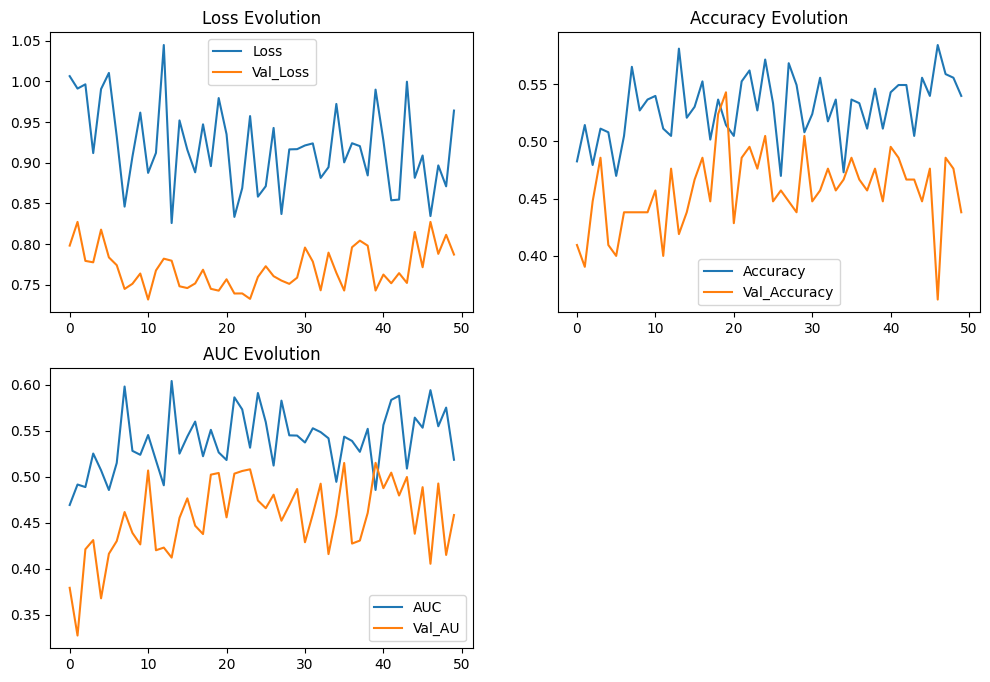

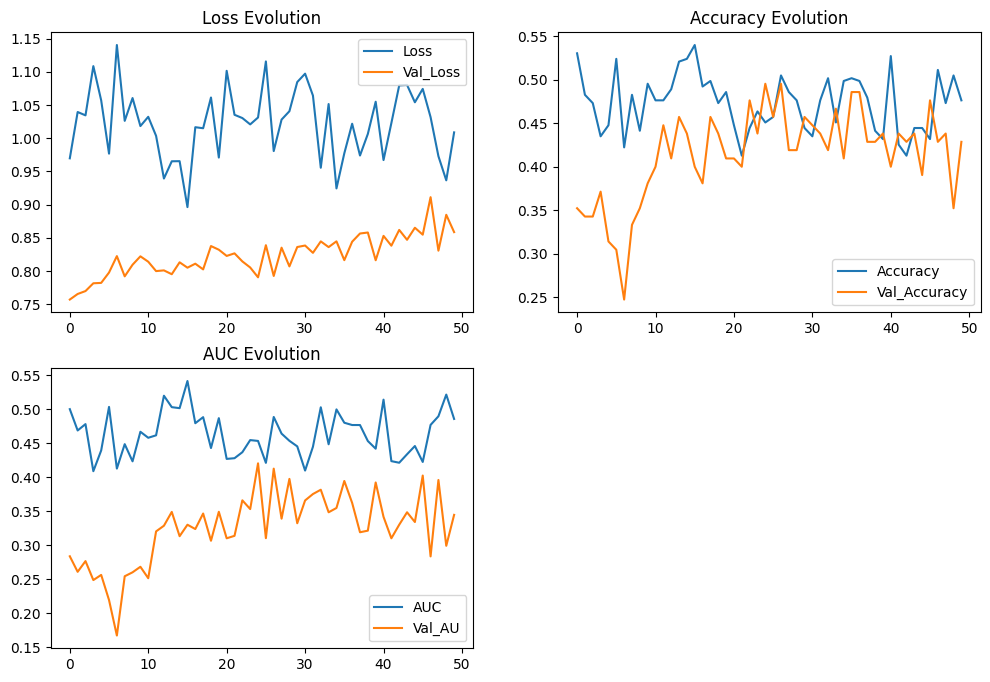

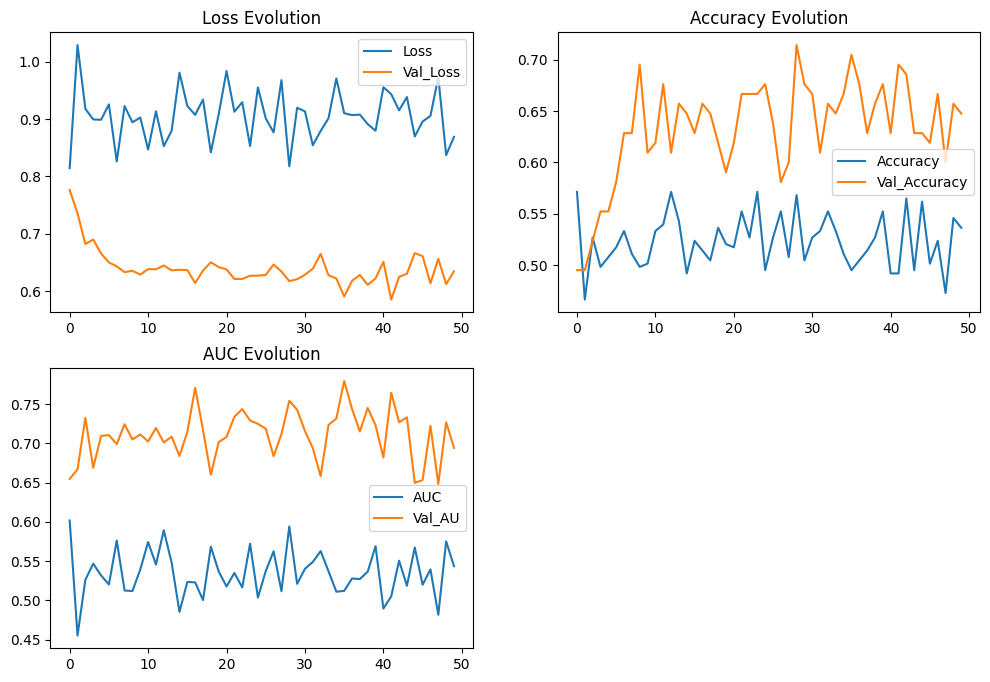

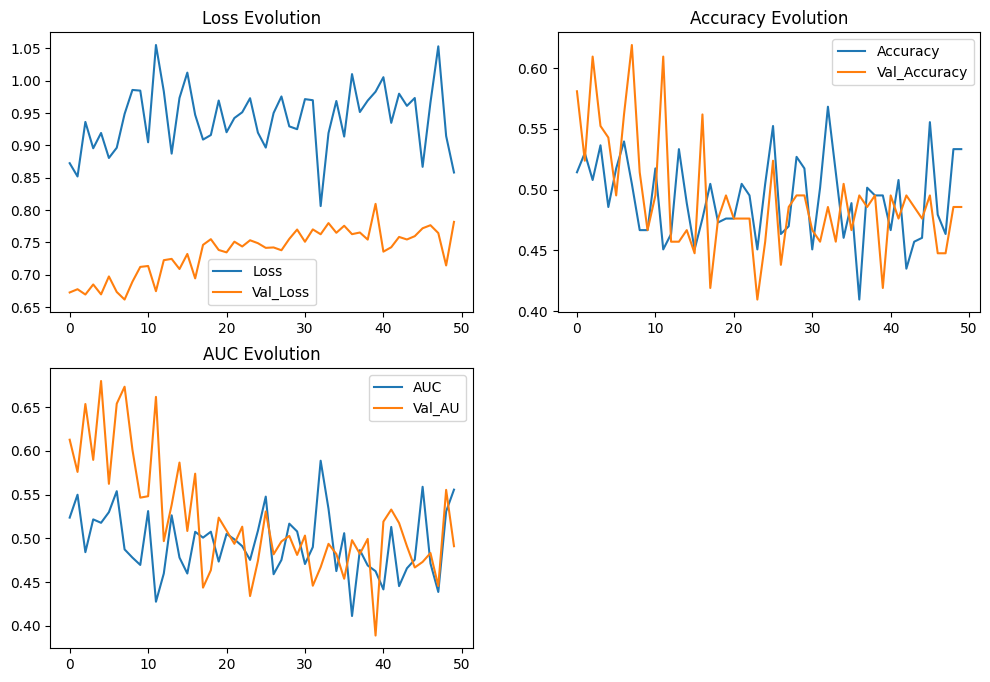

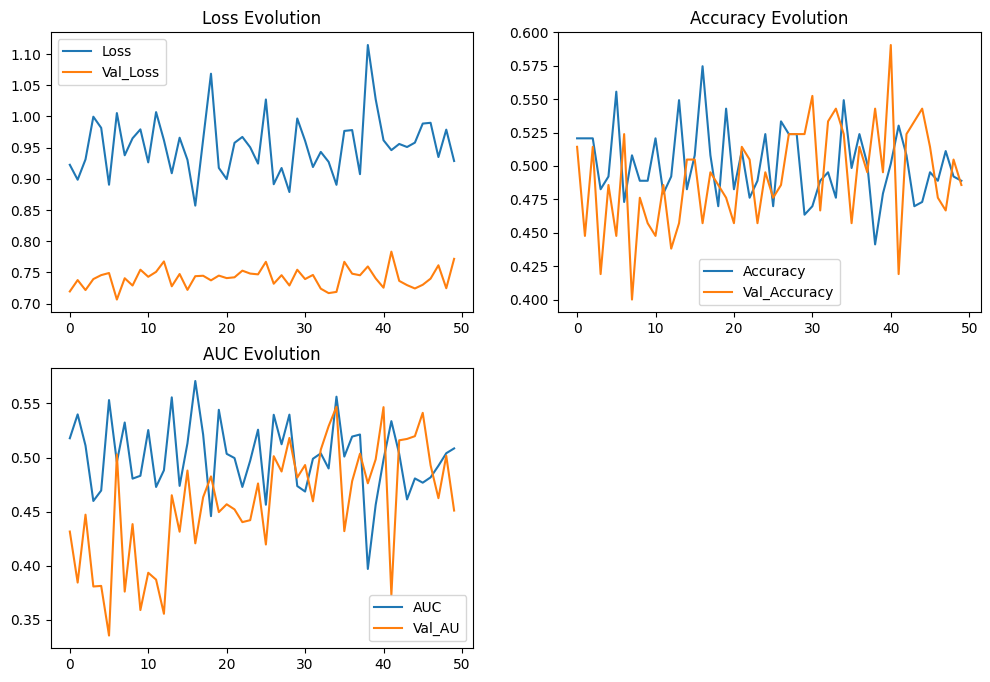

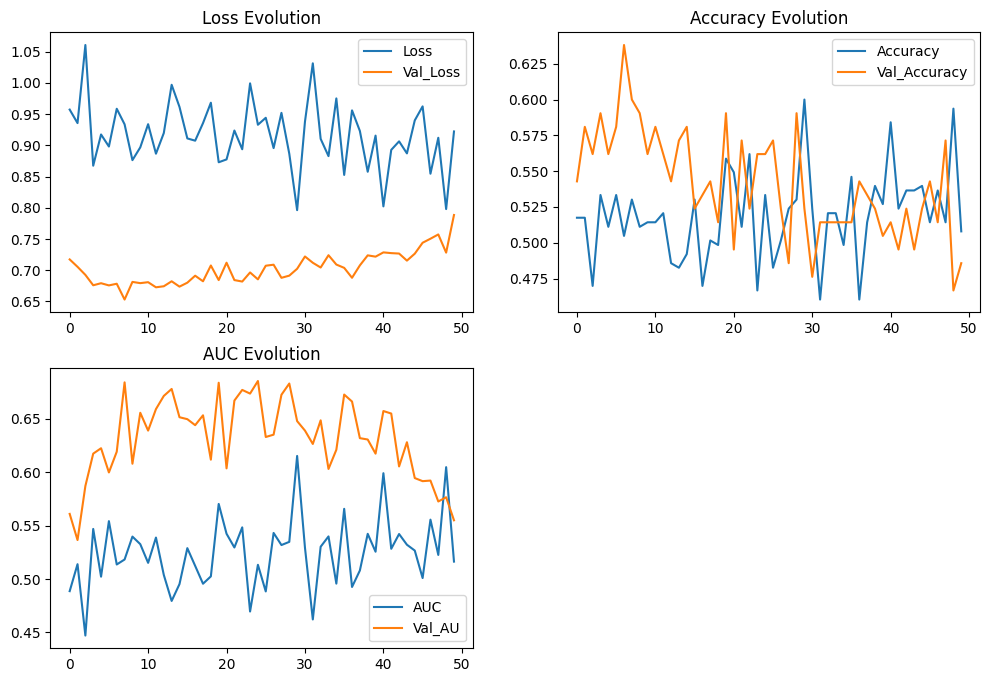

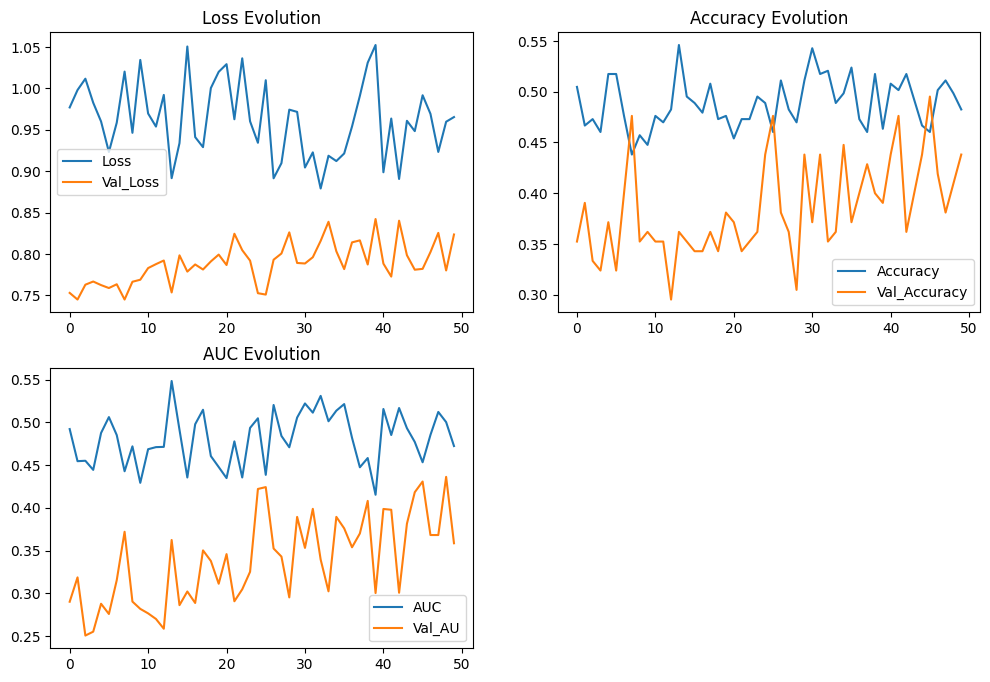

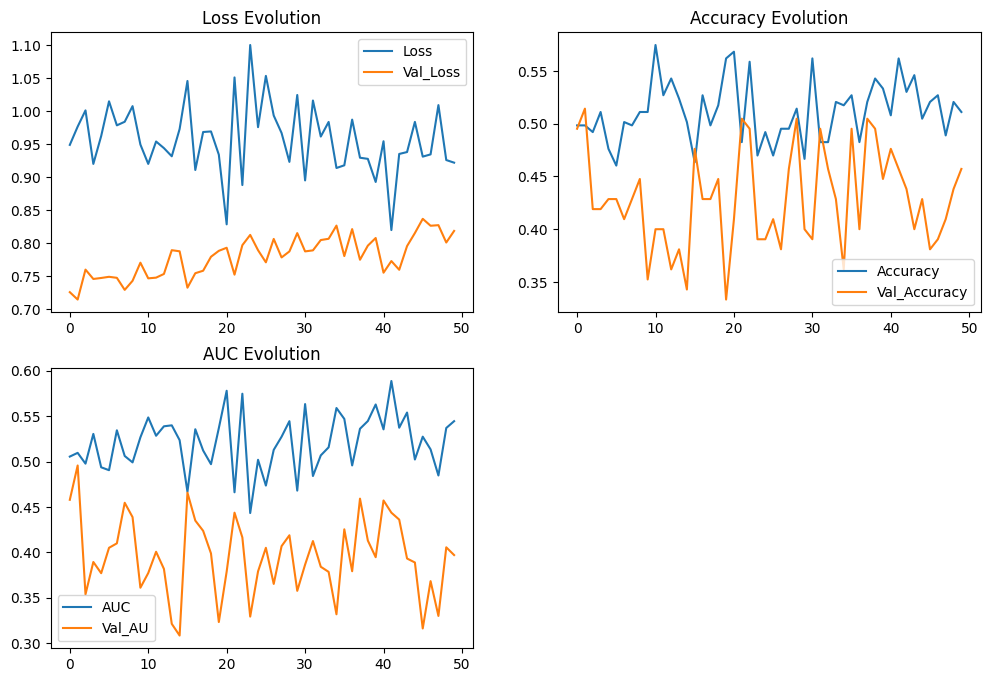

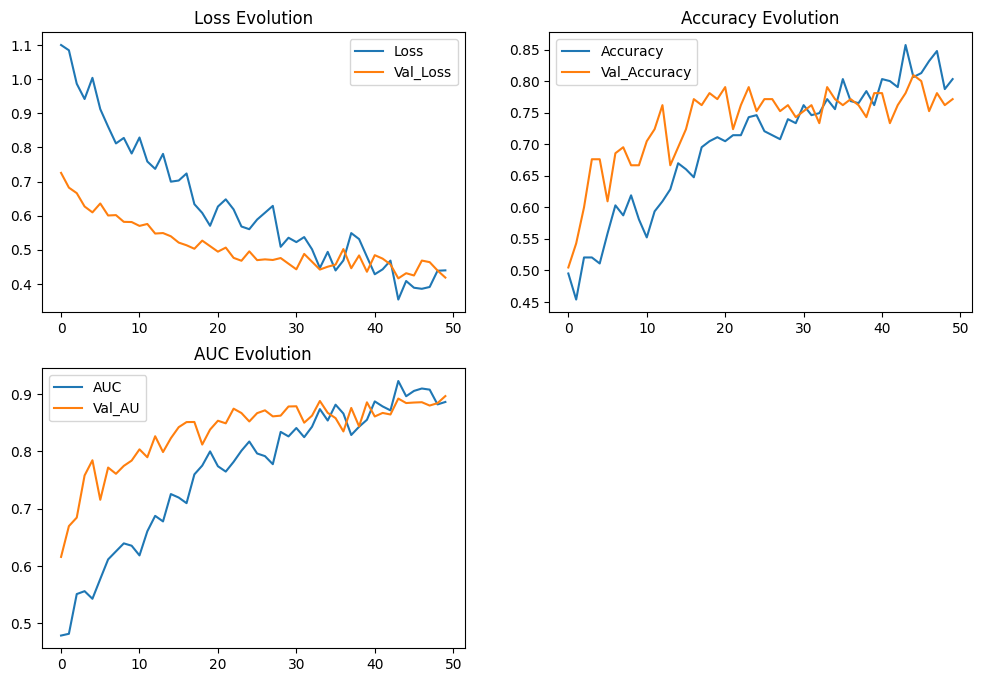

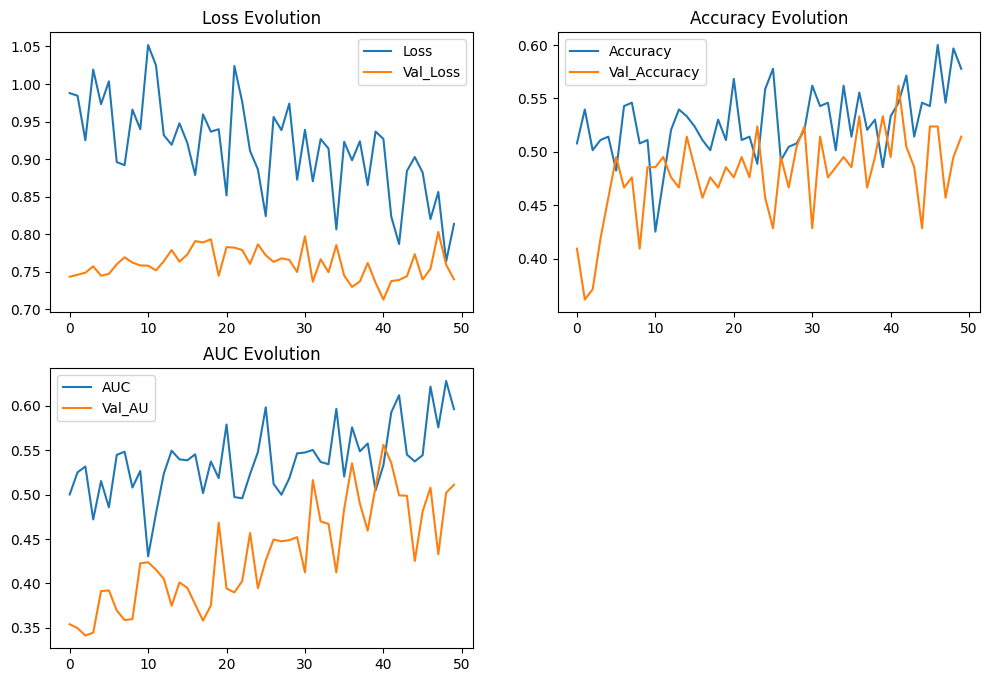

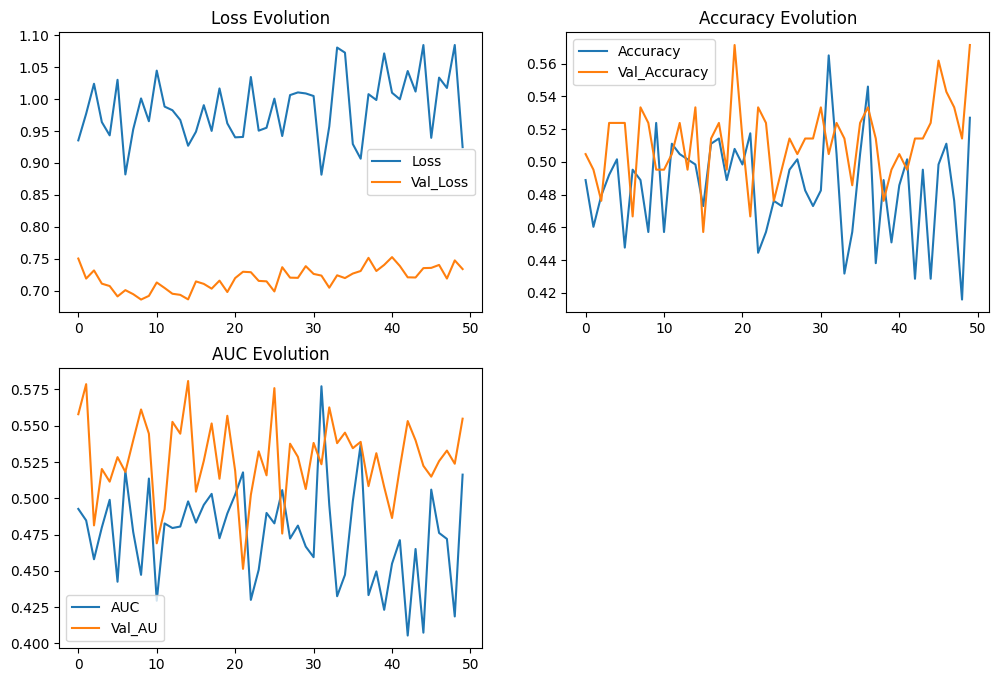

In [14]:
#densenet
set_model("densenet", 0.0001, "adam")
set_model("densenet", 0.00001, "adam")
set_model("densenet", 0.000001, "adam")

set_model("densenet", 0.0001, "adagrad")
set_model("densenet", 0.00001, "adagrad")
set_model("densenet", 0.000001, "adagrad")

set_model("densenet", 0.0001, "adamax")
set_model("densenet", 0.00001, "adamax")
set_model("densenet", 0.000001, "adamax")

set_model("densenet", 0.0001, "adadelta")
set_model("densenet", 0.00001, "adadelta")
set_model("densenet", 0.000001, "adadelta")

set_model("densenet", 0.0001, "sgd")
set_model("densenet", 0.00001, "sgd")
set_model("densenet", 0.000001, "sgd")

set_model("densenet", 0.0001, "rmsp")
set_model("densenet", 0.00001, "rmsp")
set_model("densenet", 0.000001, "rmsp")

In [15]:
#vgg
set_model("vgg", 0.0001, "adam")
set_model("vgg", 0.00001, "adam")
set_model("vgg", 0.000001, "adam")

set_model("vgg", 0.0001, "adagrad")
set_model("vgg", 0.00001, "adagrad")
set_model("vgg", 0.000001, "adagrad")

set_model("vgg", 0.0001, "adamax")
set_model("vgg", 0.00001, "adamax")
set_model("vgg", 0.000001, "adamax")

set_model("vgg", 0.0001, "adadelta")
set_model("vgg", 0.00001, "adadelta")
set_model("vgg", 0.000001, "adadelta")

set_model("vgg", 0.0001, "sgd")
set_model("vgg", 0.00001, "sgd")
set_model("vgg", 0.000001, "sgd")

set_model("vgg", 0.0001, "rmsp")
set_model("vgg", 0.00001, "rmsp")
set_model("vgg", 0.000001, "rmsp")


RUNNING USING MODEL: vgg AND LEARNING RATE OF 0.0001 ON adam
80134624/80134624 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
Epoch 1/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.4514 - auc: 0.4462 - loss: 1.0707 - precision: 0.4707 - recall: 0.4519 - specificity: 0.4022
F1 SCORE TRAIN: 0.4737
F1 SCORE VALIDATION: 0.0727

Epoch 1: val_accuracy did not improve from 0.80952
10/10 ━━━━━━━━━━━━━━━━━━━━ 72s 7s/step - accuracy: 0.4921 - auc: 0.4846 - loss: 1.0295 - precision: 0.4932 - recall: 0.4557 - specificity: 0.4968 - val_accuracy: 0.5143 - val_auc: 0.5923 - val_loss: 0.6892 - val_precision: 0.6667 - val_recall: 0.0385 - val_specificity: 0.4717
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.5139 - auc: 0.5479 - loss: 0.8848 - precision: 0.5433 - recall: 0.4743 - specificity: 0.5255
F1 SCORE TRAIN: 0.5033
F1 SCORE VALIDATION: 0.0364

Epoch 2: val_accuracy did not improve from 0.80952
10/10 ━━━━━━━━━━━━━━━━━━━━ 64s 7s/step - accuracy: 0.5175 - auc: 0.5480 - loss: 0.8925 - prec

KeyboardInterrupt: 

In [ ]:
#efficientnet
set_model("efficientnet", 0.0001, "adam")
set_model("efficientnet", 0.00001, "adam")
set_model("efficientnet", 0.000001, "adam")

set_model("efficientnet", 0.0001, "adagrad")
set_model("efficientnet", 0.00001, "adagrad")
set_model("efficientnet", 0.000001, "adagrad")

set_model("efficientnet", 0.0001, "adamax")
set_model("efficientnet", 0.00001, "adamax")
set_model("efficientnet", 0.000001, "adamax")

set_model("efficientnet", 0.0001, "adadelta")
set_model("efficientnet", 0.00001, "adadelta")
set_model("efficientnet", 0.000001, "adadelta")

set_model("efficientnet", 0.0001, "sgd")
set_model("efficientnet", 0.00001, "sgd")
set_model("efficientnet", 0.000001, "sgd")

set_model("efficientnet", 0.0001, "rmsp")
set_model("efficientnet", 0.00001, "rmsp")
set_model("efficientnet", 0.000001, "rmsp")


In [ ]:
#vgg
set_model("vgg", 0.0001, "adam")
set_model("vgg", 0.00001, "adam")
set_model("vgg", 0.000001, "adam")

set_model("vgg", 0.0001, "adagrad")
set_model("vgg", 0.00001, "adagrad")
set_model("vgg", 0.000001, "adagrad")

set_model("vgg", 0.0001, "adamax")
set_model("vgg", 0.00001, "adamax")
set_model("vgg", 0.000001, "adamax")

set_model("vgg", 0.0001, "adadelta")
set_model("vgg", 0.00001, "adadelta")
set_model("vgg", 0.000001, "adadelta")

set_model("vgg", 0.0001, "sgd")
set_model("vgg", 0.00001, "sgd")
set_model("vgg", 0.000001, "sgd")

set_model("vgg", 0.0001, "rmsp")
set_model("vgg", 0.00001, "rmsp")
set_model("vgg", 0.000001, "rmsp")
